In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import seaborn as sns
from datetime import date
import scipy.stats as stats

In [2]:
df = pd.read_csv("data/car_price.csv",  index_col=0)

In [3]:
df

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats
...,...,...,...,...,...,...,...,...,...
5507,BMW X1 sDrive 20d xLine,28.90 Lakh,"45,000 kms",Diesel,Automatic,1st Owner,2018,2995 cc,7 Seats
5508,BMW M Series M4 Coupe,64.90 Lakh,"29,000 kms",Petrol,Automatic,2nd Owner,2015,1968 cc,5 Seats
5509,Jaguar XF 2.2 Litre Luxury,13.75 Lakh,"90,000 kms",Diesel,Automatic,2nd Owner,2013,2755 cc,5 Seats
5510,BMW 7 Series 730Ld,29.90 Lakh,"79,000 kms",Diesel,Automatic,3rd Owner,2015,2967 cc,6 Seats


In [4]:
brands = [
    "Land Rover",
    "Mercedes-Benz",
    "Mitsubishi",
    "Chevrolet",
    "Volkswagen",
    "Mahindra",
    "Hyundai",
    "Renault",
    "Porsche",
    "Maserati",
    "Maruti",
    "Toyota",
    "Premier",
    "Jaguar",
    "Datsun",
    "Skoda",
    "Lexus",
    "Volvo",
    "Honda",
    "Nissan",
    "Force",
    "Jeep",
    "Mini",
    "Ford",
    "Audi",
    "BMW",
    "Kia",
    "MG",
    "Fiat",
    "Tata"
]

# Longest brand names first
brands = sorted(brands, key=len, reverse=True)

def split_brand_model(car_name):
    for brand in brands:
        if car_name.startswith(brand):
            model = car_name[len(brand):].strip()
            return pd.Series([brand, model])
    return pd.Series(["Unknown", car_name])

df[["brand", "model"]] = df["car_name"].apply(split_brand_model)

In [5]:
df

,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats,brand,model
0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats,Jeep,Compass 2.0 Longitude Option BSIV
1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats,Renault,Duster RXZ Turbo CVT
2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats,Toyota,Camry 2.5 G
3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats,Honda,Jazz VX CVT
4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats,Volkswagen,Polo 1.2 MPI Highline
...,...,...,...,...,...,...,...,...,...,...,...
5507,BMW X1 sDrive 20d xLine,28.90 Lakh,"45,000 kms",Diesel,Automatic,1st Owner,2018,2995 cc,7 Seats,BMW,X1 sDrive 20d xLine
5508,BMW M Series M4 Coupe,64.90 Lakh,"29,000 kms",Petrol,Automatic,2nd Owner,2015,1968 cc,5 Seats,BMW,M Series M4 Coupe
5509,Jaguar XF 2.2 Litre Luxury,13.75 Lakh,"90,000 kms",Diesel,Automatic,2nd Owner,2013,2755 cc,5 Seats,Jaguar,XF 2.2 Litre Luxury
5510,BMW 7 Series 730Ld,29.90 Lakh,"79,000 kms",Diesel,Automatic,3rd Owner,2015,2967 cc,6 Seats,BMW,7 Series 730Ld


In [6]:
import pandas as pd
df = pd.read_csv('data/car_price.csv')
df['engine_cc'] = df['engine'].str.replace(' cc', '', regex=False).astype(float)
df['brand'] = df['car_name'].str.split().str[0]
df['model'] = df['car_name'].str.split(n=1).str[1]

# 0 cc check — EV models ko alag rakho
ev_keywords = ['EV', 'Electric', 'e2o', 'Nexon EV']
df['is_ev'] = df['car_name'].str.contains('|'.join(ev_keywords), case=False, na=False)

print(df[(df['engine_cc']==0) & (~df['is_ev'])][['car_name','engine_cc']])

                               car_name  engine_cc
630             BMW X1 sDrive 20d xLine        0.0
746            Maruti Wagon R VXI BS IV        0.0
1212                    Tata Harrier XM        0.0
1548  Renault KWID Climber 1.0 AMT BSIV        0.0
1758           Honda City i-VTEC CVT VX        0.0
1944                       Honda City E        0.0
1968                   Kia Seltos HTE D        0.0
2175             Honda CR-V 2.0L 2WD AT        0.0
4745          Hyundai Xcent 1.2 CRDi SX        0.0
5254  Ford Ecosport 1.5 DV5 MT Titanium        0.0


In [7]:
def fix_engine(group):
    valid = group[(group['engine_cc'] > 0) & (group['engine_cc'] < 3500)]
    if valid.empty:
        return group['engine_cc']
    mode_val = valid['engine_cc'].mode()
    if mode_val.empty:
        return group['engine_cc']
    correct_val = mode_val.iloc[0]
    # Replace only clearly wrong values (outside plausible range or too different)
    fixed = group['engine_cc'].apply(
        lambda x: correct_val if (x <= 0 or x > 3500 or abs(x-correct_val)/correct_val > 0.3) else x
    )
    return fixed

df['engine_cc_fixed'] = df.groupby('model', group_keys=False).apply(fix_engine)

C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\1201666667.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['engine_cc_fixed'] = df.groupby('model', group_keys=False).apply(fix_engine)


In [8]:
# Still-suspicious rows after fixing
still_bad = df[(df['engine_cc_fixed'] > 3500) | (df['engine_cc_fixed'] <= 0)]
print("Rows needing manual fix or removal:", len(still_bad))

# Option 1: Drop these rows for prediction model
df_clean = df[~df.index.isin(still_bad.index)].copy()

# Option 2: Or manually map known correct values for these specific models

Rows needing manual fix or removal: 12


In [9]:
df.loc[(df['engine_cc']==0) & (~df['is_ev']), 'engine_cc'] = None

In [10]:
car = df.copy()

In [11]:
car.drop("car_name", axis=1, inplace=True)

In [12]:
car = car[['brand' , 'model', 'fuel_type' , 'manufacture' ,'transmission', 'kms_driven', 'engine', 'Seats', 'ownership', 'car_prices_in_rupee']]

In [13]:
car.rename(columns={"car_prices_in_rupee": "car_prices"}, inplace=True)

In [14]:
car

,brand,model,fuel_type,manufacture,transmission,kms_driven,engine,Seats,ownership,car_prices
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,2017,Manual,"86,226 kms",1956 cc,5 Seats,1st Owner,10.03 Lakh
1,Renault,Duster RXZ Turbo CVT,Petrol,2021,Automatic,"13,248 kms",1330 cc,5 Seats,1st Owner,12.83 Lakh
2,Toyota,Camry 2.5 G,Petrol,2016,Automatic,"60,343 kms",2494 cc,5 Seats,1st Owner,16.40 Lakh
3,Honda,Jazz VX CVT,Petrol,2018,Automatic,"26,696 kms",1199 cc,5 Seats,1st Owner,7.77 Lakh
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,2016,Manual,"69,414 kms",1199 cc,5 Seats,1st Owner,5.15 Lakh
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,2018,Automatic,"45,000 kms",2995 cc,7 Seats,1st Owner,28.90 Lakh
5508,BMW,M Series M4 Coupe,Petrol,2015,Automatic,"29,000 kms",1968 cc,5 Seats,2nd Owner,64.90 Lakh
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,2013,Automatic,"90,000 kms",2755 cc,5 Seats,2nd Owner,13.75 Lakh
5510,BMW,7 Series 730Ld,Diesel,2015,Automatic,"79,000 kms",2967 cc,6 Seats,3rd Owner,29.90 Lakh


In [15]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         5512 non-null   object
 1   model         5512 non-null   object
 2   fuel_type     5512 non-null   object
 3   manufacture   5512 non-null   int64 
 4   transmission  5512 non-null   object
 5   kms_driven    5512 non-null   object
 6   engine        5512 non-null   object
 7   Seats         5512 non-null   object
 8   ownership     5512 non-null   object
 9   car_prices    5512 non-null   object
dtypes: int64(1), object(9)
memory usage: 430.8+ KB


In [16]:
car['kms_driven'].isnull().sum()

np.int64(0)

In [17]:
car["kms_driven"] = (
    car["kms_driven"]
    .astype(str)
    .str.split()
    .str[0]
    .str.replace(",", "", regex=False)
    .astype(int)
)


In [18]:
car.head()

,brand,model,fuel_type,manufacture,transmission,kms_driven,engine,Seats,ownership,car_prices
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,2017,Manual,86226,1956 cc,5 Seats,1st Owner,10.03 Lakh
1,Renault,Duster RXZ Turbo CVT,Petrol,2021,Automatic,13248,1330 cc,5 Seats,1st Owner,12.83 Lakh
2,Toyota,Camry 2.5 G,Petrol,2016,Automatic,60343,2494 cc,5 Seats,1st Owner,16.40 Lakh
3,Honda,Jazz VX CVT,Petrol,2018,Automatic,26696,1199 cc,5 Seats,1st Owner,7.77 Lakh
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,2016,Manual,69414,1199 cc,5 Seats,1st Owner,5.15 Lakh


In [19]:
def convert_price(car_prices):
    price = str(car_prices).strip()

    if "Crore" in car_prices:
        return int(float(car_prices.replace(" Crore", "")) * 10000000)

    elif "Lakh" in car_prices:
        return int(float(car_prices.replace(" Lakh", "")) * 100000)

    else:
        return int(float(car_prices.replace(",", "")))

car["car_prices"] = car["car_prices"].apply(convert_price)

In [20]:
car['engine']= (
    car['engine']
    .astype(str)
    .str.split()
    .str[0]
    .astype(int)
)
car['Seats']= (
    car['Seats']
    .str.split()
    .str[0]
    .astype(int)
)    


In [21]:
car.head()

,brand,model,fuel_type,manufacture,transmission,kms_driven,engine,Seats,ownership,car_prices
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,2017,Manual,86226,1956,5,1st Owner,1002999
1,Renault,Duster RXZ Turbo CVT,Petrol,2021,Automatic,13248,1330,5,1st Owner,1283000
2,Toyota,Camry 2.5 G,Petrol,2016,Automatic,60343,2494,5,1st Owner,1639999
3,Honda,Jazz VX CVT,Petrol,2018,Automatic,26696,1199,5,1st Owner,777000
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,2016,Manual,69414,1199,5,1st Owner,515000


In [22]:
current_year =  date.today().year

In [23]:
current_year

2026

In [24]:
car["age"] = current_year - car['manufacture']

In [25]:
car.drop(columns = ['manufacture'] , inplace=True)

In [26]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199,5,1st Owner,515000,10
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995,7,1st Owner,2890000,8
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968,5,2nd Owner,6490000,11
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755,5,2nd Owner,1375000,13
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967,6,3rd Owner,2990000,11


In [27]:
# car['ownership']= car['ownership'].str.split().str[0]

In [28]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(15, 8))
# plt.scatter(car.index, car["car_prices"])
# # sns.scatter(data=df[num_cols])

# plt.xticks(rotation=90)
# plt.title("Outliers in Numerical Columns")
# plt.show()

In [29]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199,5,1st Owner,515000,10
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995,7,1st Owner,2890000,8
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968,5,2nd Owner,6490000,11
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755,5,2nd Owner,1375000,13
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967,6,3rd Owner,2990000,11


<Axes: xlabel='count', ylabel='brand'>

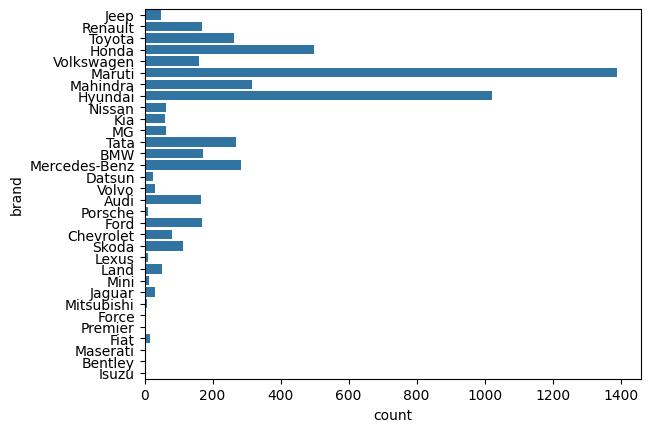

In [30]:
sns.countplot(car["brand"])

<Axes: xlabel='fuel_type', ylabel='count'>

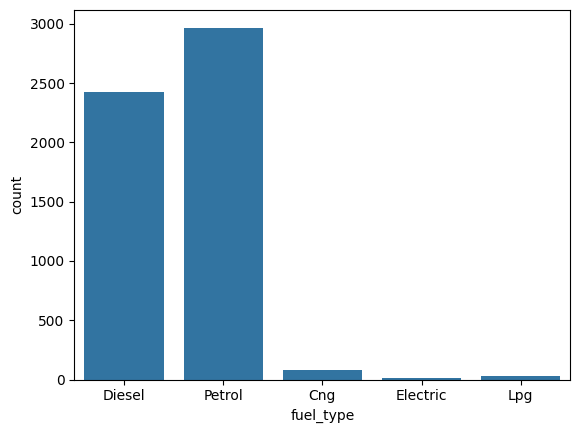

In [31]:
sns.countplot(x = car['fuel_type'])

<Axes: xlabel='transmission', ylabel='count'>

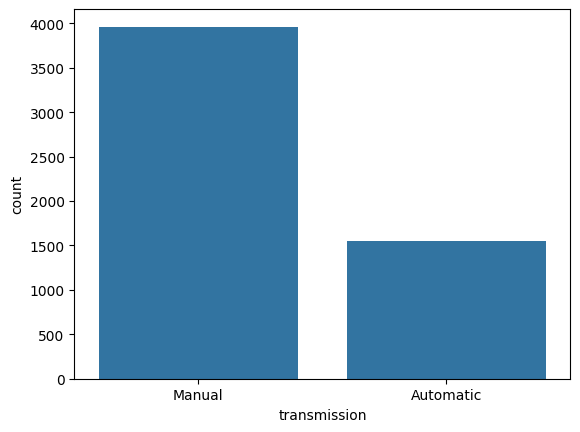

In [32]:
sns.countplot(x = car['transmission'] )

<Axes: xlabel='engine'>

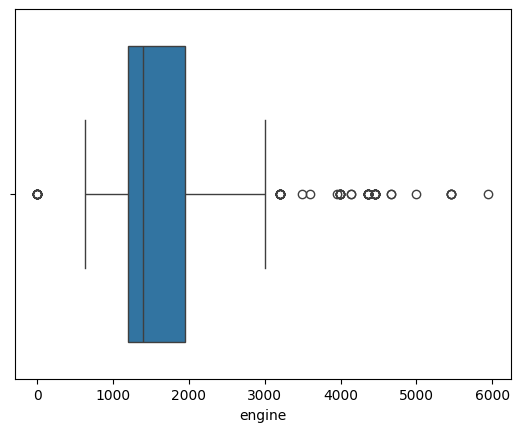

In [33]:
sns.boxplot(x = car['engine'])

In [34]:
car[car["engine"]==0]

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
288,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,24374,0,5,1st Owner,418000,5
311,Mahindra,e2o T2,Electric,Automatic,54112,0,5,1st Owner,321000,12
630,BMW,X1 sDrive 20d xLine,Diesel,Automatic,22000,0,5,1st Owner,4375000,6
746,Maruti,Wagon R VXI BS IV,Petrol,Manual,100527,0,5,1st Owner,236000,14
1212,Tata,Harrier XM,Diesel,Manual,33500,0,5,1st Owner,1260000,7
1548,Renault,KWID Climber 1.0 AMT BSIV,Petrol,Automatic,30000,0,5,1st Owner,470000,7
1758,Honda,City i-VTEC CVT VX,Petrol,Automatic,65855,0,5,1st Owner,950000,7
1944,Honda,City E,Petrol,Manual,77132,0,5,1st Owner,300000,14
1968,Kia,Seltos HTE D,Diesel,Manual,35343,0,5,1st Owner,1182000,5
2175,Honda,CR-V 2.0L 2WD AT,Petrol,Automatic,74000,0,7,1st Owner,1550000,10


In [35]:
car[car["model"] == 'Ecosport 1.5 DV5 MT Titanium']

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
66,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,78264,1498,5,2nd Owner,509000,11
175,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,78000,1498,5,1st Owner,590000,11
509,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,80000,1248,5,2nd Owner,600000,13
1204,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,62500,1582,5,1st Owner,475000,11
1412,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,71000,1968,5,1st Owner,409999,12
1532,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,62500,1950,5,1st Owner,475000,11
1759,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,113706,2523,8,2nd Owner,484999,12
2083,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,121000,1497,5,1st Owner,545000,13
2639,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,80000,993,5,3rd Owner,300000,13
2850,Ford,Ecosport 1.5 DV5 MT Titanium,Diesel,Manual,120000,796,5,2nd Owner,425000,12


In [36]:
car[car["model"] == "Ecosport 1.5 DV5 MT Titanium"]["engine"].value_counts()

engine
1498    2
1248    1
1582    1
1968    1
1950    1
2523    1
1497    1
993     1
796     1
1798    1
1598    1
999     1
1199    1
1197    1
0       1
Name: count, dtype: int64

In [37]:
car["engine"] = car["engine"].replace(0, np.nan)

In [38]:
# Filter rows for this specific model
mask = car['model'] == 'Ecosport 1.5 DV5 MT Titanium'

# Set correct engine value (1498, since that's the true spec + most frequent)
car.loc[mask, 'engine'] = 1498

# Verify
print(car.loc[mask, 'engine'].value_counts())

engine
1498.0    16
Name: count, dtype: int64


<Axes: xlabel='engine'>

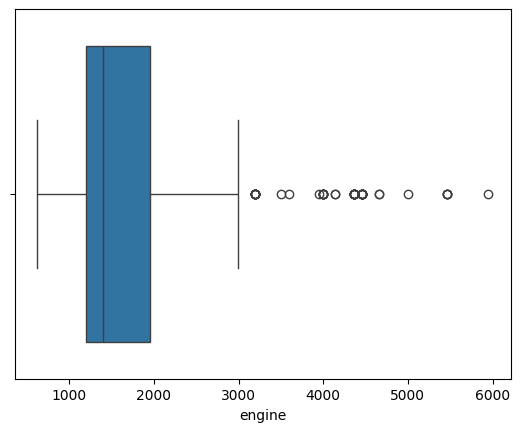

In [39]:
sns.boxplot(x = car['engine'])

In [40]:
print("NaN count:", car['engine'].isna().sum())
print(car[car['engine'].isna()][['brand','model','engine']])

NaN count: 11
         brand                       model  engine
288       Tata  Nexon EV Prime XZ Plus LUX     NaN
311   Mahindra                      e2o T2     NaN
630        BMW         X1 sDrive 20d xLine     NaN
746     Maruti           Wagon R VXI BS IV     NaN
1212      Tata                  Harrier XM     NaN
1548   Renault   KWID Climber 1.0 AMT BSIV     NaN
1758     Honda          City i-VTEC CVT VX     NaN
1944     Honda                      City E     NaN
1968       Kia                Seltos HTE D     NaN
2175     Honda            CR-V 2.0L 2WD AT     NaN
4745   Hyundai           Xcent 1.2 CRDi SX     NaN


In [41]:
# ev_keywords = ['e2o', 'EV', 'Electric']
# car['is_ev'] = car['model'].str.contains('|'.join(ev_keywords), case=False, na=False)

# # EV wali NaN ko 0 kar do (genuine — EV mein engine hota hi nahi)
# car.loc[car['is_ev'] & car['engine'].isna(), 'engine'] = 0

In [42]:
# known_specs = {
#     'KWID Climber 1.0 AMT BSIV': 999,
#     'City i-VTEC CVT VX': 1497,
# }

# for model, correct_val in known_specs.items():
#     car.loc[car['model'] == model, 'engine'] = correct_val

In [43]:
print("Remaining NaN:", car['engine'].isna().sum())
car[car['engine'].isna()]  # empty aana chahiye

Remaining NaN: 11


,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
288,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,24374,NaN,5,1st Owner,418000,5
311,Mahindra,e2o T2,Electric,Automatic,54112,NaN,5,1st Owner,321000,12
630,BMW,X1 sDrive 20d xLine,Diesel,Automatic,22000,NaN,5,1st Owner,4375000,6
746,Maruti,Wagon R VXI BS IV,Petrol,Manual,100527,NaN,5,1st Owner,236000,14
1212,Tata,Harrier XM,Diesel,Manual,33500,NaN,5,1st Owner,1260000,7
1548,Renault,KWID Climber 1.0 AMT BSIV,Petrol,Automatic,30000,NaN,5,1st Owner,470000,7
1758,Honda,City i-VTEC CVT VX,Petrol,Automatic,65855,NaN,5,1st Owner,950000,7
1944,Honda,City E,Petrol,Manual,77132,NaN,5,1st Owner,300000,14
1968,Kia,Seltos HTE D,Diesel,Manual,35343,NaN,5,1st Owner,1182000,5
2175,Honda,CR-V 2.0L 2WD AT,Petrol,Automatic,74000,NaN,7,1st Owner,1550000,10


In [44]:
# For every model, replace engine values with the most frequent (mode) value for that model
# car['engine'] = car.groupby('model')['engine'].transform(
#     lambda x: x.mode()[0] if not x.mode().empty else x
# )

In [45]:
car[car["model"] == 'Jazz VX CVT']

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8
1705,Honda,Jazz VX CVT,Petrol,Automatic,22000,1199.0,5,1st Owner,789000,7
4698,Honda,Jazz VX CVT,Petrol,Automatic,94834,1499.0,5,1st Owner,623000,8


In [46]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956.0,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330.0,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494.0,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199.0,5,1st Owner,515000,10
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995.0,7,1st Owner,2890000,8
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968.0,5,2nd Owner,6490000,11
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755.0,5,2nd Owner,1375000,13
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967.0,6,3rd Owner,2990000,11


In [47]:
# Load your data
# df = pd.read_csv('your_file.csv')

# Step 1: Group by model and check unique engine count
engine_check = car.groupby('model')['engine'].nunique()

# Step 2: Filter models jinke andar 1 se zyada unique engine values hain
inconsistent_models = engine_check[engine_check > 1].index

# Step 3: Un models ke saare rows nikalo
inconsistent_data = car[car['model'].isin(inconsistent_models)]

# Step 4: Sort karo model wise taaki easily compare kar sako
inconsistent_data = inconsistent_data.sort_values(by=['model', 'engine'])

# Result dekho
print(f"Total models with inconsistent engine values: {len(inconsistent_models)}")
print(inconsistent_data)

Total models with inconsistent engine values: 968
        brand                  model fuel_type transmission  kms_driven  \
4619      BMW  2 Series 220i M Sport    Petrol    Automatic       18000   
5471      BMW  2 Series 220i M Sport    Petrol    Automatic        5000   
84        BMW  2 Series 220i M Sport    Petrol    Automatic       18000   
4926      BMW  2 Series 220i M Sport    Petrol    Automatic       18000   
4405      BMW  2 Series 220i M Sport    Petrol    Automatic       18000   
...       ...                    ...       ...          ...         ...   
2764  Hyundai   i20 Sportz Plus BSIV    Petrol       Manual       30000   
2982  Hyundai   i20 Sportz Plus BSIV    Petrol       Manual       35986   
3904  Hyundai   i20 Sportz Plus BSIV    Petrol       Manual       35000   
5501  Hyundai   i20 Sportz Plus BSIV    Petrol       Manual       45000   
2583  Hyundai   i20 Sportz Plus BSIV    Petrol       Manual       17500   

      engine  Seats  ownership  car_prices  age  

Text(0.5, 1.0, 'car price accourding to power ')

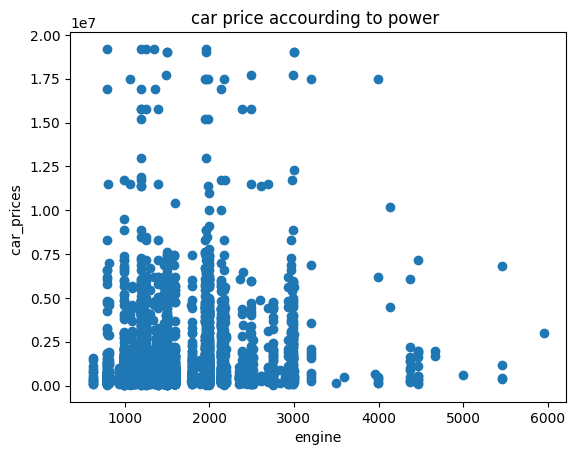

In [48]:
plt.scatter(car['engine'], car['car_prices'])
plt.xlabel("engine")
plt.ylabel("car_prices ")
plt.title("car price accourding to power ")

In [49]:
car[car["engine"]>3200]

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
64,Porsche,Cayenne S Diesel,Diesel,Automatic,48894,4134.0,5,1st Owner,4500000,12
595,Hyundai,Creta 1.6 CRDi AT SX Plus,Diesel,Automatic,63000,4461.0,5,1st Owner,1100000,9
696,Maruti,Wagon R LXI CNG,Cng,Manual,47756,4461.0,5,1st Owner,341000,10
720,Maruti,Baleno RS 1.0 Petrol,Petrol,Manual,17700,3956.0,5,2nd Owner,636000,9
855,Toyota,Innova 2.5 EV (Diesel) MS 7 Seater BS IV,Diesel,Manual,113000,4461.0,5,1st Owner,550000,15
926,Ford,Fiesta 1.4 ZXi Duratec,Petrol,Manual,179000,4461.0,7,2nd Owner,150000,17
1071,Hyundai,Verna 1.6 SX,Diesel,Manual,116064,5461.0,5,2nd Owner,407000,13
1072,Ford,Classic 1.4 Duratorq Titanium,Diesel,Manual,128396,3996.0,4,1st Owner,158000,14
1196,Mercedes-Benz,M-Class ML 250 CDI,Diesel,Automatic,80000,4367.0,5,2nd Owner,2190000,12
1200,Audi,A6 2.0 TDI Premium Plus,Diesel,Automatic,82005,4367.0,5,2nd Owner,1425000,13


In [50]:
car[car['engine'] == 'nun' ]

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age


In [51]:
car['ownership'].unique()

array(['1st Owner', '2nd Owner', '3rd Owner', '4th Owner', '5th Owner',
       '0th Owner'], dtype=object)

In [52]:
car[car["ownership"] == '0th Owner']

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
2139,Volkswagen,Virtus Topline AT,Petrol,Automatic,7020,999.0,5,0th Owner,1700000,4
2140,Volkswagen,Virtus Highline AT,Petrol,Automatic,3638,1498.0,5,0th Owner,1500000,4
2141,Volkswagen,Virtus Topline,Petrol,Manual,4792,1956.0,5,0th Owner,1525000,4
2142,Volkswagen,Virtus GT Plus,Petrol,Automatic,11193,1197.0,5,0th Owner,1925000,4
2916,Audi,A6 45 TFSI Technology,Petrol,Automatic,16000,1968.0,5,0th Owner,5780000,5
4268,Audi,A6 45 TFSI Technology,Petrol,Automatic,16000,1968.0,5,0th Owner,5780000,5
5478,Mercedes-Benz,C-Class C 220d,Diesel,Automatic,9000,1462.0,5,0th Owner,5300000,4


In [53]:
car = car[car["ownership"] != "0th Owner"]

In [54]:
car[car["ownership"] == '0th Owner']

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age


In [55]:
# Engine displacement realistically kabhi bhi 6000cc se zyada nahi hota (except rare supercars)
# Aur zyada common cars ke liye range 600cc - 4000cc hi hota hai

# Flag suspicious engine values
suspicious = car[(car['engine'] > 3500) | (car['engine'] < 600)]
print(suspicious[['brand', 'model', 'engine']].drop_duplicates())

              brand                                     model  engine
64          Porsche                          Cayenne S Diesel  4134.0
595         Hyundai                 Creta 1.6 CRDi AT SX Plus  4461.0
696          Maruti                           Wagon R LXI CNG  4461.0
720          Maruti                      Baleno RS 1.0 Petrol  3956.0
855          Toyota  Innova 2.5 EV (Diesel) MS 7 Seater BS IV  4461.0
926            Ford                    Fiesta 1.4 ZXi Duratec  4461.0
1071        Hyundai                              Verna 1.6 SX  5461.0
1072           Ford             Classic 1.4 Duratorq Titanium  3996.0
1196  Mercedes-Benz                        M-Class ML 250 CDI  4367.0
1200           Audi                   A6 2.0 TDI Premium Plus  4367.0
1257           Tata                            Harrier XZA AT  4461.0
1307           Land    Rover Range Rover Evoque 2.2L Prestige  5950.0
1325  Mercedes-Benz                        A Class A180 Sport  4663.0
1474        Renault 

In [56]:
# Model-wise correct engine value nikaalo (jo range mein ho, 0 < x < 3500)
def get_correct_engine(group):
    valid = group[(group > 0) & (group <= 3500)]
    if valid.empty:
        return None
    return valid.mode().iloc[0] if not valid.mode().empty else valid.median()

model_correct_engine = car.groupby('model')['engine'].apply(get_correct_engine)

# Ab wrong values (>3500 ya 0) ko replace karo
def fix_row(row):
    if row['engine'] > 3500 or row['engine'] == 0:
        correct = model_correct_engine.get(row['model'])
        return correct if correct is not None else row['engine']
    return row['engine']

car['engine'] = car.apply(fix_row, axis=1)

C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\1323904023.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['engine'] = car.apply(fix_row, axis=1)


<Axes: xlabel='engine'>

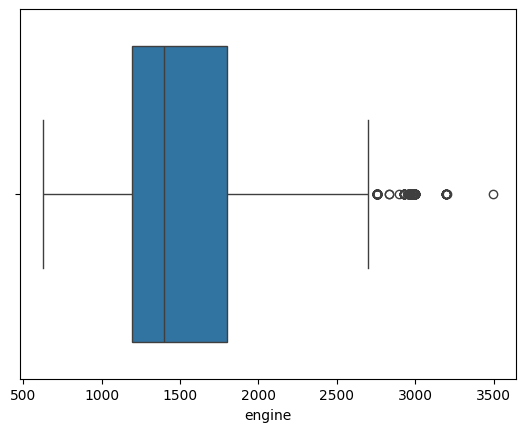

In [57]:
sns.boxplot(x=car['engine'])

In [58]:
still_bad = car[(car['engine'] > 3500) | (car['engine'] == 0)]
print(len(still_bad))
car = car[~car.index.isin(still_bad.index)]

0


Text(0.5, 1.0, 'car price accourding to power ')

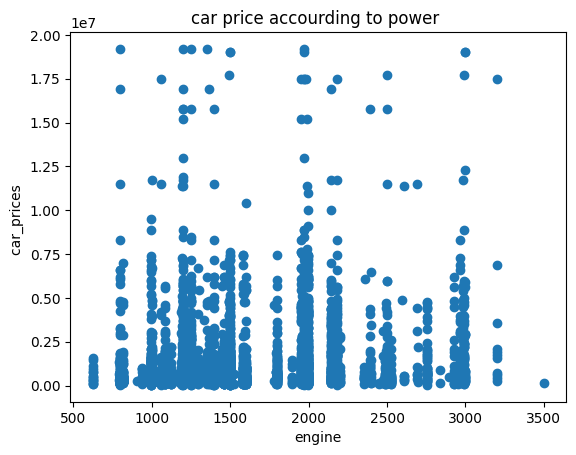

In [59]:
plt.scatter(car['engine'], car['car_prices'])
plt.xlabel("engine")
plt.ylabel("car_prices ")
plt.title("car price accourding to power ")

In [60]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956.0,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330.0,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494.0,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199.0,5,1st Owner,515000,10
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995.0,7,1st Owner,2890000,8
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968.0,5,2nd Owner,6490000,11
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755.0,5,2nd Owner,1375000,13
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967.0,6,3rd Owner,2990000,11


<Axes: xlabel='kms_driven'>

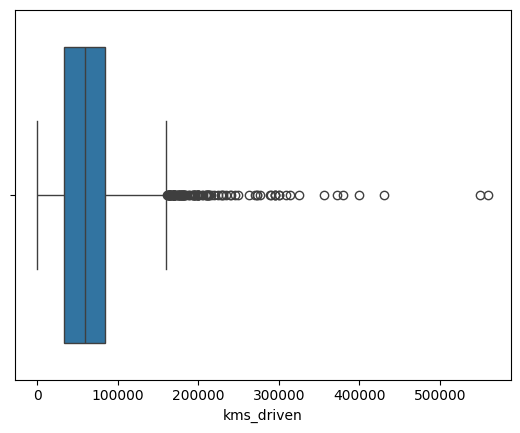

In [61]:
sns.boxplot(x = car['kms_driven'])

In [62]:
# Realistic average: ek car saalana ~15,000-20,000 km chalti hai (India mein)
# car["kms_per_year"] = car['kms_driven']/ car["age"]
car['kms_per_year'] = car['kms_driven'] / car['age']

# Agar kms_per_year bahut zyada hai (jaise >60,000/year), to suspicious hai
suspicious_kms = car[car['kms_per_year'] > 60000]
print(suspicious_kms[['brand','model','kms_driven','age','kms_per_year']])

       brand            model  kms_driven  age  kms_per_year
1662  Maruti  Baleno 1.2 Zeta      560000    9  62222.222222


In [63]:
# drop where car['kms_per_year'] > 60000
suspicious_kms = car[car['kms_per_year'] > 60000]
car = car.drop(suspicious_kms.index)

In [64]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age,kms_per_year
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956.0,5,1st Owner,1002999,9,9580.666667
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330.0,5,1st Owner,1283000,5,2649.600000
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494.0,5,1st Owner,1639999,10,6034.300000
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8,3337.000000
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199.0,5,1st Owner,515000,10,6941.400000
...,...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995.0,7,1st Owner,2890000,8,5625.000000
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968.0,5,2nd Owner,6490000,11,2636.363636
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755.0,5,2nd Owner,1375000,13,6923.076923
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967.0,6,3rd Owner,2990000,11,7181.818182


In [65]:
car[car["kms_driven"]>500000]

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age,kms_per_year
4905,Maruti,Ciaz VXi Plus,Petrol,Manual,549999,2494.0,5,1st Owner,550000,11,49999.909091


<Axes: xlabel='kms_driven'>

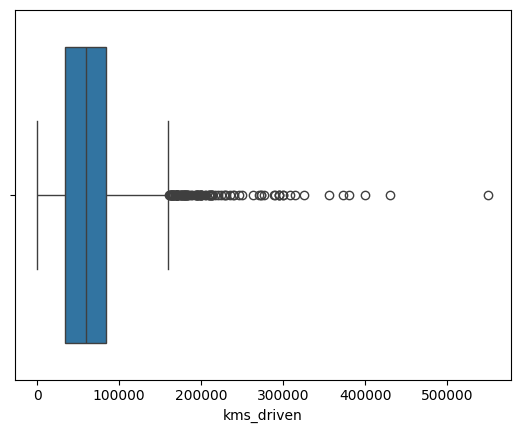

In [66]:
sns.boxplot(x = car['kms_driven'])

In [67]:
car = car.drop(columns=["kms_per_year"])

In [68]:
car

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956.0,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330.0,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494.0,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199.0,5,1st Owner,515000,10
...,...,...,...,...,...,...,...,...,...,...
5507,BMW,X1 sDrive 20d xLine,Diesel,Automatic,45000,2995.0,7,1st Owner,2890000,8
5508,BMW,M Series M4 Coupe,Petrol,Automatic,29000,1968.0,5,2nd Owner,6490000,11
5509,Jaguar,XF 2.2 Litre Luxury,Diesel,Automatic,90000,2755.0,5,2nd Owner,1375000,13
5510,BMW,7 Series 730Ld,Diesel,Automatic,79000,2967.0,6,3rd Owner,2990000,11


In [69]:
# Q1 = car["engine"].quantile(0.25)
# Q3 = car["engine"].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# print("Lower:", lower)
# print("Upper:", upper)

# outliers = car[(car["engine"] < lower) | (car["engine"] > upper)]

# print(outliers["engine"].sort_values())

In [70]:
# outliers.shape

In [71]:
car.loc[car['engine']==0 , ['brand', 'model' , 'engine']]


,brand,model,engine


<Axes: xlabel='transmission', ylabel='engine'>

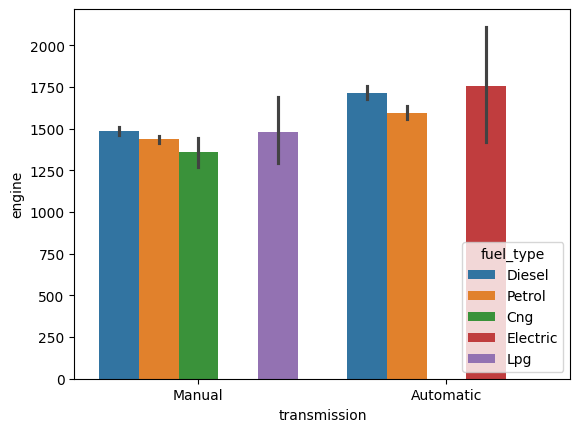

In [72]:
sns.barplot(data = car , x = "transmission" , y = "engine" , hue="fuel_type" )

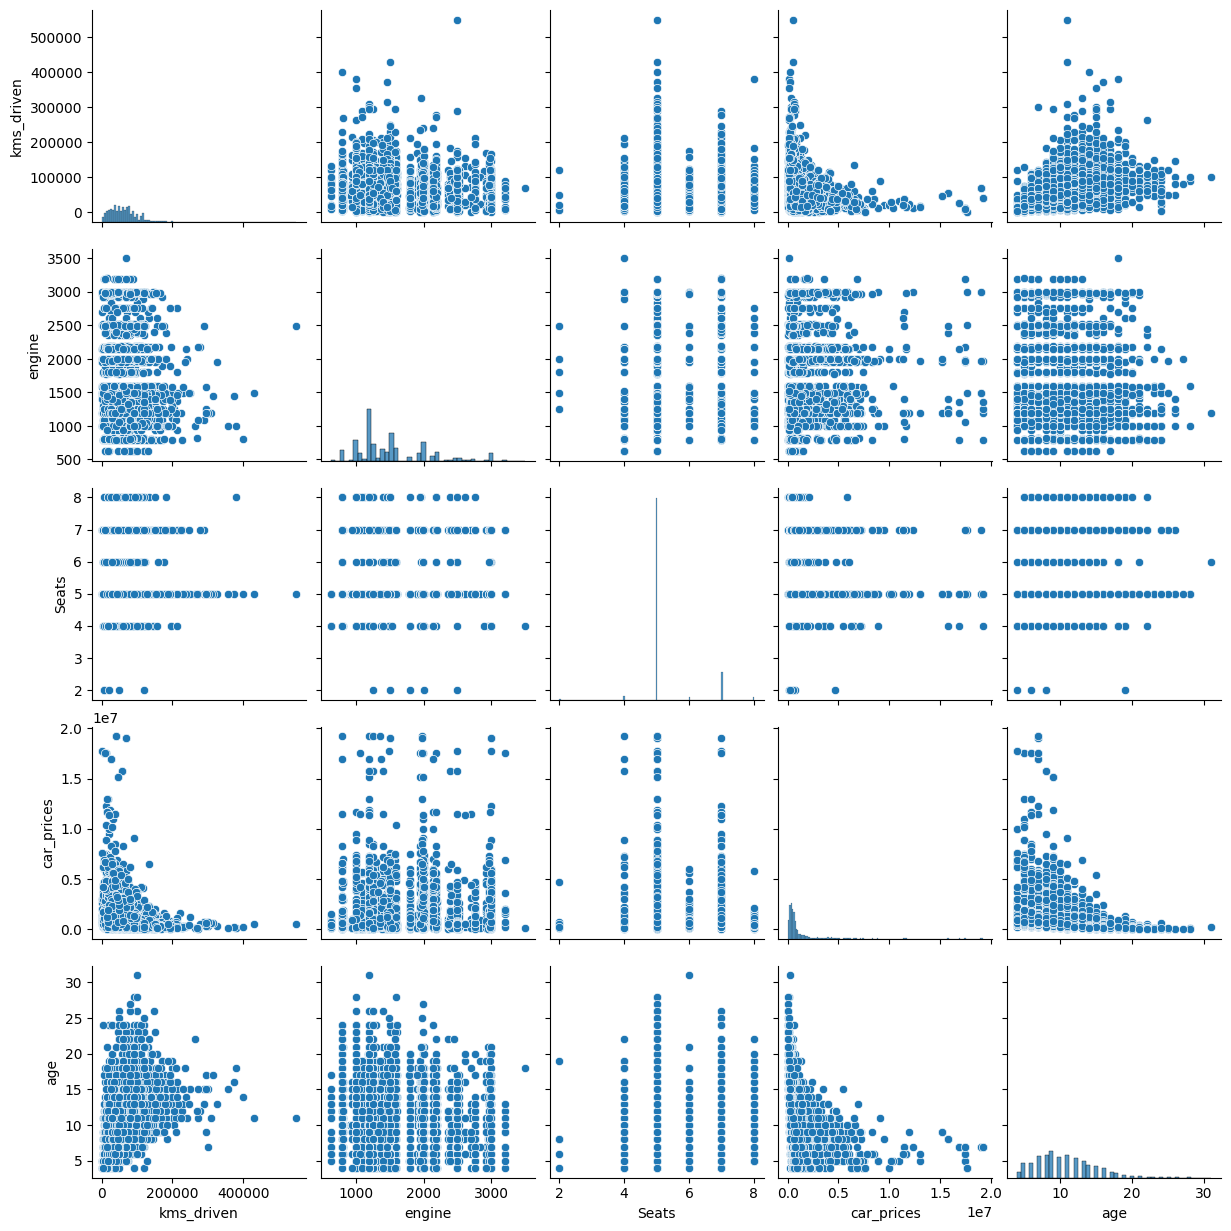

In [73]:
sns.pairplot(car)

Text(0.5, 1.0, 'age on QQ plot')

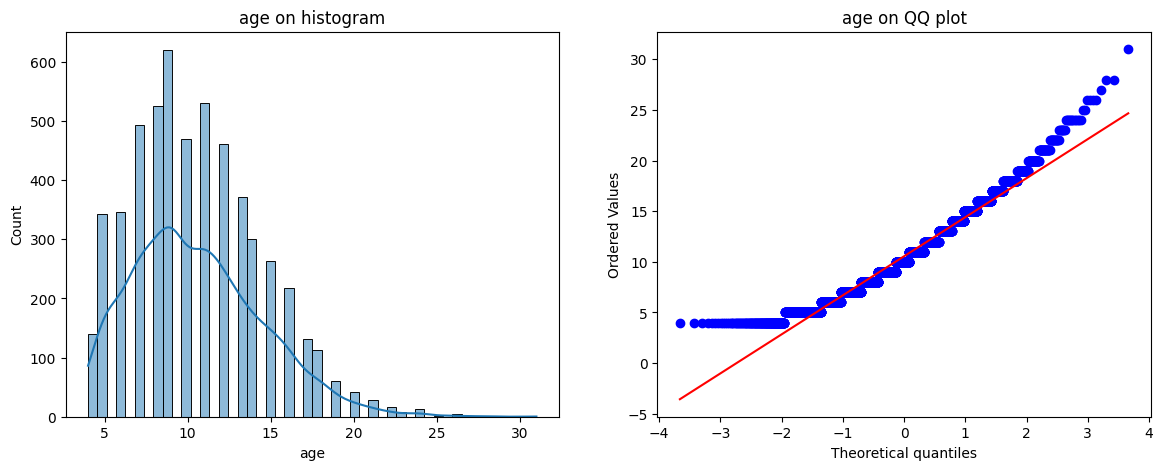

In [74]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(car["age"] , kde=True)
plt.title("age on histogram")

plt.subplot(122)
stats.probplot(car["age"]  , plot=plt)
plt.title("age on QQ plot" )

In [75]:
car['age'].skew()

np.float64(0.645140694937935)

Text(0.5, 1.0, 'engine on QQ plot')

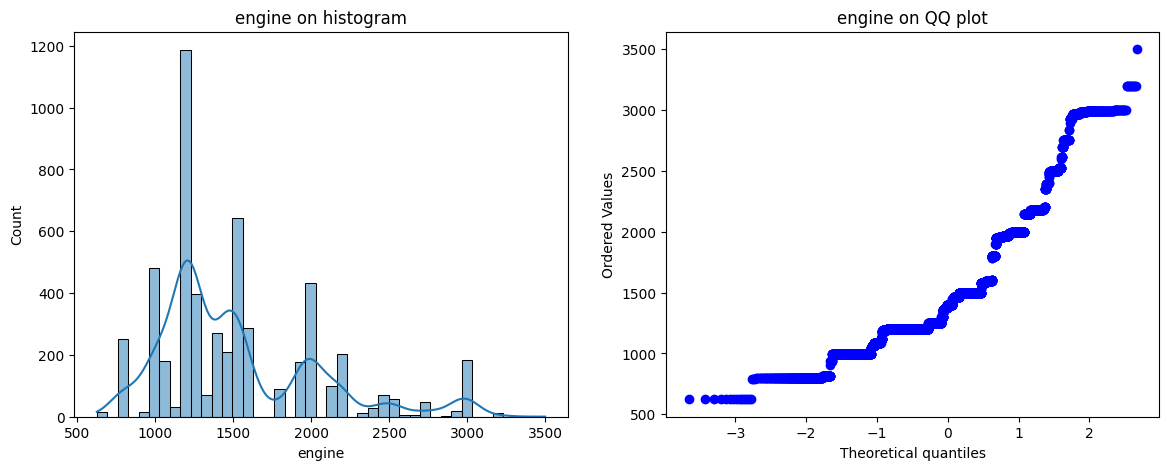

In [76]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(car["engine"] , kde=True)
plt.title("engine on histogram")

plt.subplot(122)
stats.probplot(car["engine"]  , plot=plt)
plt.title("engine on QQ plot" )

In [77]:
car['engine'].skew()

np.float64(1.1786218161681137)

Text(0.5, 1.0, 'kms_driven on QQ plot')

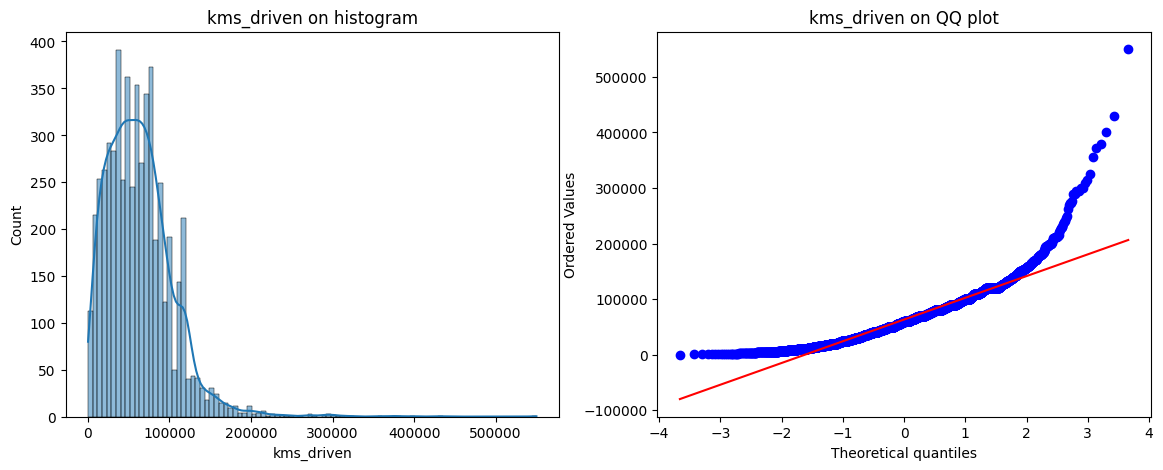

In [78]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(car["kms_driven"] , kde=True)
plt.title("kms_driven on histogram")

plt.subplot(122)
stats.probplot(car["kms_driven"]  , plot=plt)
plt.title("kms_driven on QQ plot" )

In [79]:
car['kms_driven'].skew()

np.float64(1.8127057560999689)

In [80]:
car.skew(numeric_only=True)

kms_driven    1.812706
engine        1.178622
Seats         1.994728
car_prices    4.874975
age           0.645141
dtype: float64

Text(0.5, 1.0, 'Seats on QQ plot')

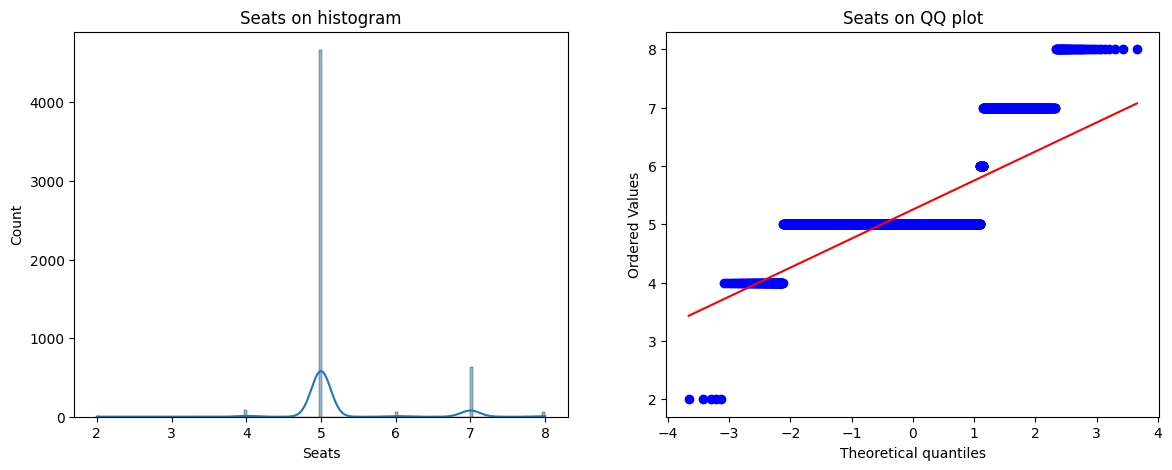

In [81]:
plt.figure(figsize=(14,5))
plt.subplot(121)
sns.histplot(car["Seats"] , kde=True)
plt.title("Seats on histogram")

plt.subplot(122)
stats.probplot(car["Seats"]  , plot=plt)
plt.title("Seats on QQ plot" )

<Axes: xlabel='Seats', ylabel='count'>

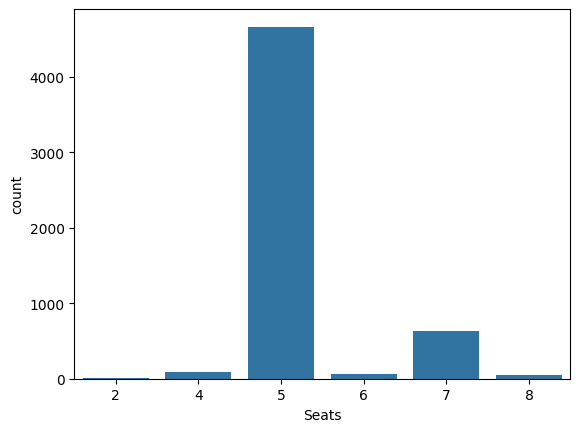

In [82]:
sns.countplot(x = car['Seats'])

<Axes: xlabel='age', ylabel='car_prices'>

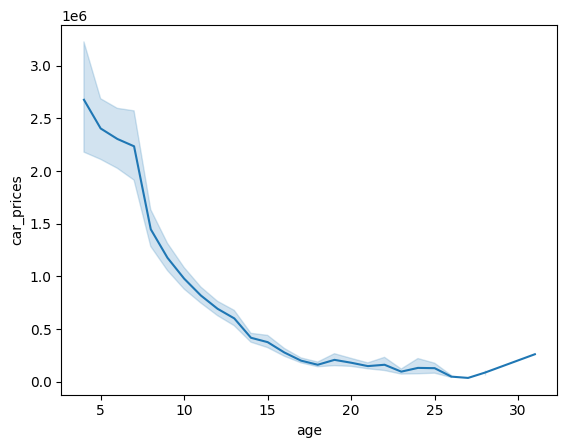

In [83]:
sns.lineplot(data = car ,x =  car['age'] , y = car['car_prices'] )

<Axes: xlabel='engine'>

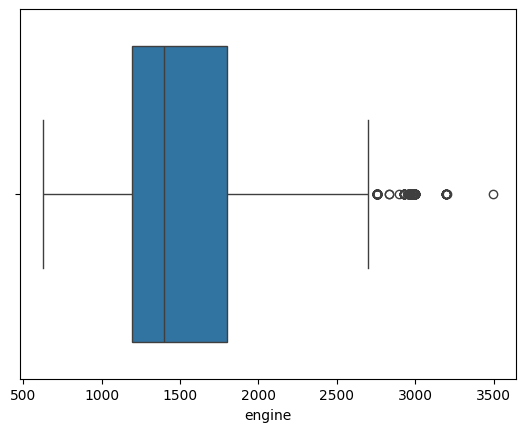

In [84]:
sns.boxplot(x=car['engine'])

<Axes: xlabel='age', ylabel='engine'>

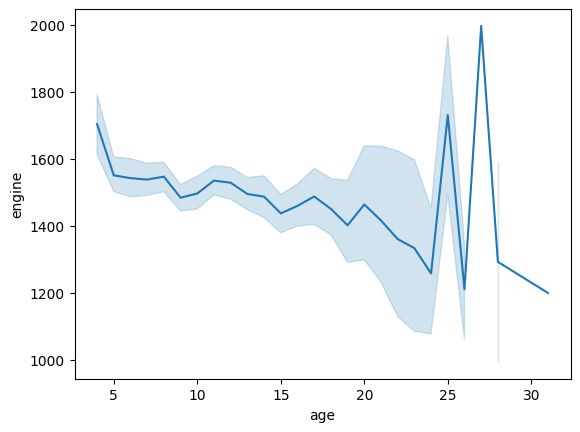

In [85]:
sns.lineplot(data = car ,x =  car['age'] , y = car['engine'] )

In [86]:
car.head()

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
0,Jeep,Compass 2.0 Longitude Option BSIV,Diesel,Manual,86226,1956.0,5,1st Owner,1002999,9
1,Renault,Duster RXZ Turbo CVT,Petrol,Automatic,13248,1330.0,5,1st Owner,1283000,5
2,Toyota,Camry 2.5 G,Petrol,Automatic,60343,2494.0,5,1st Owner,1639999,10
3,Honda,Jazz VX CVT,Petrol,Automatic,26696,1199.0,5,1st Owner,777000,8
4,Volkswagen,Polo 1.2 MPI Highline,Petrol,Manual,69414,1199.0,5,1st Owner,515000,10


In [87]:
len(car['model'].unique())

1891

In [88]:
car['ownership'].unique()

array(['1st Owner', '2nd Owner', '3rd Owner', '4th Owner', '5th Owner'],
      dtype=object)

In [89]:
#1. use onehotencoder on fuel_type , transmission , brand
# 2. use ordinalencoder on ownership 
# 3. use category_encoders on model 
# 4. power transformer on kms_driven, engine
#5. use this on pipeline 


# note = power transformer is best than log transformer for engine and kms_driven :

                        #engine 
    
                # power transformer ka skew = 0.027175839562398888
                # log transformer ka skew = -0.5849577483666676

                    #kms _driven 

                #power trransform ka skew = 0.005942926546856857
                #log transform ka skew = -1.1542043656604972


In [90]:
#use transform on engime 

In [91]:
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import FunctionTransformer

In [92]:
pt = PowerTransformer(method="yeo-johnson")
car['power_engine'] = pt.fit_transform(car[["engine"]])

In [93]:
trf = FunctionTransformer(func=np.log1p)

In [94]:
car['log_engine'] = trf.fit_transform(car[['engine']])

C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\1846608352.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car['power_engine'])
C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\1846608352.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = car['log_engine'])


Text(0.5, 1.0, 'log power transformer ')

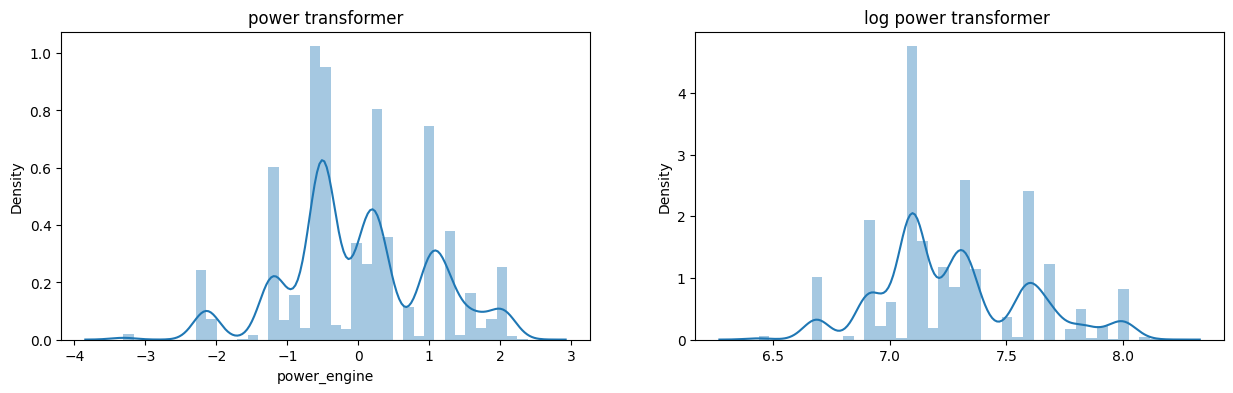

In [95]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.distplot(car['power_engine'])
plt.title('power transformer')

plt.subplot(122)
sns.distplot(x = car['log_engine'])
plt.title('log power transformer ')

In [96]:
car["power_engine"].skew()

np.float64(0.012888356698814853)

In [97]:
car['log_engine'].skew()

np.float64(0.4398050085717574)

In [98]:
pt = PowerTransformer(method="yeo-johnson")
car['power_kms_driven'] = pt.fit_transform(car[["kms_driven"]])

In [99]:
trf = FunctionTransformer(func=np.log1p)
car['log_kms_driven'] = trf.fit_transform(car[['kms_driven']])

C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\3688828161.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(car['power_kms_driven'])
C:\Users\yashs\AppData\Local\Temp\ipykernel_12232\3688828161.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = car['log_kms_driven'])


Text(0.5, 1.0, 'log kms_driven ')

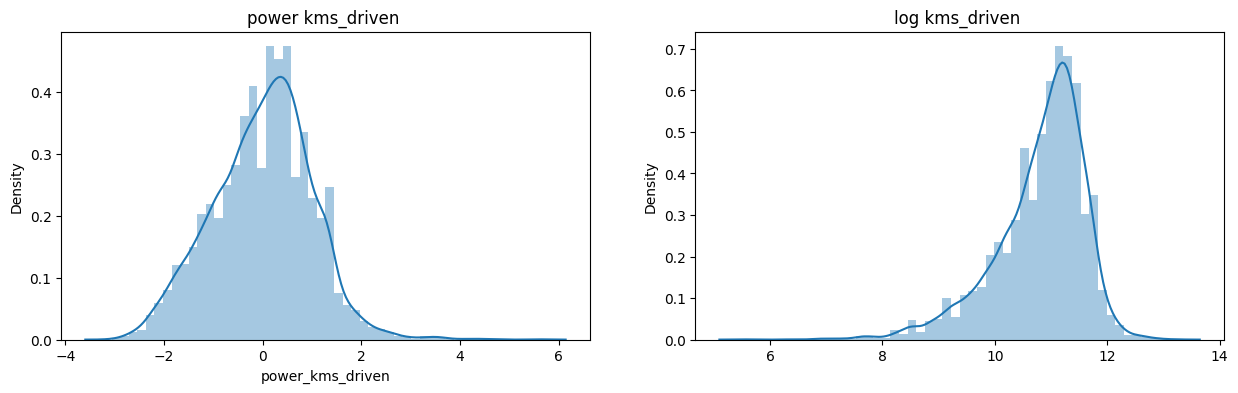

In [100]:
plt.figure(figsize=(15,4))
plt.subplot(121)
sns.distplot(car['power_kms_driven'])
plt.title('power kms_driven ')

plt.subplot(122)
sns.distplot(x = car['log_kms_driven'])
plt.title('log kms_driven ')

In [101]:
car['power_kms_driven'].skew()

np.float64(0.006928983643982497)

In [102]:
car['log_kms_driven'].skew()

np.float64(-1.1561758899588)

In [103]:
car = car.drop(columns=["log_engine", "power_engine" , "power_kms_driven" , "log_kms_driven"])

In [104]:
car.isnull().mean()*100

brand           0.000000
model           0.000000
fuel_type       0.000000
transmission    0.000000
kms_driven      0.000000
engine          0.363372
Seats           0.000000
ownership       0.000000
car_prices      0.000000
age             0.000000
dtype: float64

In [105]:
car['engine'].isna().sum()

np.int64(20)

In [106]:
# Same brand ke baaki cars ka median engine use karo (better than dropping)
car['engine'] = car.groupby('brand')['engine'].transform(
    lambda x: x.fillna(x.median())
)

In [107]:
print("Remaining NaN:", car['engine'].isna().sum())

Remaining NaN: 0


In [108]:
car['engine'] = car['engine'].fillna(car['engine'].median())
print("Final check:", car['engine'].isna().sum())  

Final check: 0


In [109]:
car['engine'].isnull().sum()

np.int64(0)

In [110]:
car[car["fuel_type"] == 'Electric']

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age
288,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,24374,1396.0,5,1st Owner,418000,5
311,Mahindra,e2o T2,Electric,Automatic,54112,1461.0,5,1st Owner,321000,12
631,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,10000,2993.0,5,1st Owner,1550000,4
747,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,54239,799.0,5,1st Owner,367000,6
1214,MG,ZS EV Exclusive,Electric,Automatic,38000,1950.0,5,1st Owner,2110000,6
1550,MG,ZS EV Exclusive,Electric,Automatic,38000,1998.0,5,1st Owner,2110000,6
1760,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,40000,1497.0,8,1st Owner,1450000,6
1794,Toyota,Camry Hybrid,Electric,Automatic,50000,1969.0,7,1st Owner,2300000,11
1946,MG,ZS EV Exclusive,Electric,Automatic,28000,1968.0,5,1st Owner,2185000,5
1970,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,54239,1373.0,7,1st Owner,367000,6


In [111]:
# Electric cars ka engine = 0
car.loc[car['fuel_type'] == 'Electric', 'engine'] = 0

# New column is_ev
car['is_ev'] = car['fuel_type'].apply(
    lambda x: 'ev' if x == 'Electric' else 'non_ev'
)

In [112]:
car['is_ev'] = (car['fuel_type'] == 'Electric').astype(int)

In [113]:
car[car["fuel_type"]== "Electric"]

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,car_prices,age,is_ev
288,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,24374,0.0,5,1st Owner,418000,5,1
311,Mahindra,e2o T2,Electric,Automatic,54112,0.0,5,1st Owner,321000,12,1
631,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,10000,0.0,5,1st Owner,1550000,4,1
747,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,54239,0.0,5,1st Owner,367000,6,1
1214,MG,ZS EV Exclusive,Electric,Automatic,38000,0.0,5,1st Owner,2110000,6,1
1550,MG,ZS EV Exclusive,Electric,Automatic,38000,0.0,5,1st Owner,2110000,6,1
1760,Tata,Nexon EV Prime XZ Plus LUX,Electric,Automatic,40000,0.0,8,1st Owner,1450000,6,1
1794,Toyota,Camry Hybrid,Electric,Automatic,50000,0.0,7,1st Owner,2300000,11,1
1946,MG,ZS EV Exclusive,Electric,Automatic,28000,0.0,5,1st Owner,2185000,5,1
1970,Tata,Nexon EV Prime XZ Plus,Electric,Automatic,54239,0.0,7,1st Owner,367000,6,1


In [114]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5504 entries, 0 to 5511
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         5504 non-null   object 
 1   model         5504 non-null   object 
 2   fuel_type     5504 non-null   object 
 3   transmission  5504 non-null   object 
 4   kms_driven    5504 non-null   int64  
 5   engine        5504 non-null   float64
 6   Seats         5504 non-null   int64  
 7   ownership     5504 non-null   object 
 8   car_prices    5504 non-null   int64  
 9   age           5504 non-null   int64  
 10  is_ev         5504 non-null   int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 516.0+ KB


In [115]:
car.describe()

,kms_driven,engine,Seats,car_prices,age,is_ev
count,5504.000000,5504.000000,5504.000000,5.504000e+03,5504.000000,5504.000000
mean,63189.731831,1507.484466,5.251090,1.159826e+06,10.552689,0.002544
std,41291.082458,518.844363,0.720535,1.968524e+06,3.924388,0.050375
min,250.000000,0.000000,2.000000,3.500000e+04,4.000000,0.000000
25%,33472.250000,1197.000000,5.000000,3.150000e+05,8.000000,0.000000
50%,59132.500000,1396.000000,5.000000,5.500000e+05,10.000000,0.000000
75%,84278.500000,1798.000000,5.000000,1.025000e+06,13.000000,0.000000
max,549999.000000,3498.000000,8.000000,1.920000e+07,31.000000,1.000000


In [116]:
## if select ev and engine automaticlly 0 shoe then fuel_type also shoe electric    .. 
# and if have engine then not show electric on fuel_type

In [117]:
def resolve_model_engine(brand: str, model: str, fuel_types: list, engines: list) -> float:
    m = model.lower()
    b = brand.lower()
    f_list = [str(x).lower() for x in fuel_types]
    # 0. Electric / EV check
    if any(f == 'electric' for f in f_list) or 'ev' in m.split() or 'e2o' in m or 'electric' in m:
        return 0.0

    is_diesel = any('diesel' in f for f in f_list)
    is_petrol = any('petrol' in f for f in f_list)

    # 1. High displacement luxury / performance engines
    if '4.0' in m:
        return 3993.0 if b == 'audi' else 3982.0
    if '3.0' in m or '2993' in m:
        return 2993.0 if b == 'bmw' else (2967.0 if b in ['audi', 'volkswagen', 'porsche'] else 2982.0)

    # 2. BMW Badges
    if b == 'bmw':
        if any(x in m for x in ['30d', '530d', '630d', '730d', '730ld', 'x5 30d', 'x6 30d']):
            return 2993.0
        if any(x in m for x in ['20d', '320d', '520d', '620d', 'x1', 'x3 20d']):
            return 1995.0
        if any(x in m for x in ['20i', '320i', '330i', '530i', '30i']):
            return 1998.0
        if any(x in m for x in ['740', '750', 'x7']):
            return 2998.0

    # 3. Audi Badges
    if b == 'audi':
        if 'rs7' in m or 'rs5' in m:
            return 3993.0 if 'rs7' in m else 2894.0
        if any(x in m for x in ['50 tdi', '45 tdi', '3.0 tdi', 'q7 3.0', 'q7 45']):
            return 2967.0
        if any(x in m for x in ['35 tdi', '2.0 tdi', '40 tdi', 'a4 technology', 'a6 technology', 'q3 2.0', 'q5 2.0']):
            return 1968.0
        if any(x in m for x in ['35 tfsi', '30 tfsi']):
            return 1395.0
        if any(x in m for x in ['40 tfsi', '45 tfsi']):
            return 1984.0

    # 4. Mercedes-Benz Badges
    if 'mercedes' in b:
        if any(x in m for x in ['350 d', '350d', '350 cdi', 'e350', 'gls 350', 'gle 350', '350']):
            return 2987.0
        if any(x in m for x in ['250 d', '250d', 'c250', 'e250', 'c 250', 'e 250', 'cla 200', 'gla 200', 'gla 220']):
            return 2143.0
        if any(x in m for x in ['200 d', '200d', '220 d', '220d', 'c220', 'e220', 'c 220', 'e 220']):
            return 2143.0 if ('cdi' in m or 'c 220' in m or 'e 220' in m) else 1950.0
        if any(x in m for x in ['200', 'c200', 'e200', 'c 200', 'e 200']):
            return 1991.0

    # 5. Small city cars (800 / K10 / Santro / Kwid)
    if re.search(r'\b800\b', m):
        return 796.0
    if 'alto k10' in m or 'k10' in m.split():
        return 998.0
    if 'alto' in m and not 'k10' in m:
        return 796.0
    if 'eon' in m:
        return 998.0 if '1.0' in m else 814.0
    if 'santro' in m:
        return 1086.0
    if 'kwid' in m:
        return 999.0 if ('1.0' in m or 'climber' in m) else 799.0
    if 'redigo' in m or 'redi-go' in m:
        return 999.0 if '1.0' in m else 799.0
    if 'triber' in m:
        return 999.0

    # 6. Specific displacement parsed from model name
    disp_match = re.search(r'\b([0-5]\.[0-9])\b', m)
    if disp_match:
        val = float(disp_match.group(1))
        mapping = {
            0.8: 796.0,
            1.0: 998.0 if b in ['maruti', 'hyundai'] else 999.0,
            1.1: 1086.0,
            1.2: 1197.0 if b in ['maruti', 'hyundai'] else (1199.0 if b in ['honda', 'tata'] else 1198.0),
            1.3: 1248.0,
            1.4: 1396.0 if b == 'hyundai' else 1368.0,
            1.5: 1497.0 if (b == 'honda' and is_petrol and not is_diesel) else (1498.0 if b in ['honda', 'ford', 'volkswagen', 'skoda'] else 1493.0),
            1.6: 1582.0 if is_diesel else 1591.0,
            1.8: 1798.0 if b in ['toyota', 'skoda'] else 1799.0,
            2.0: 1968.0 if b in ['audi', 'volkswagen', 'skoda'] else (1995.0 if b == 'bmw' else (1956.0 if b in ['jeep', 'tata', 'mg'] else 1998.0)),
            2.2: 2179.0,
            2.4: 2393.0 if b == 'toyota' else 2354.0,
            2.5: 2494.0 if b == 'toyota' else 2487.0,
            2.7: 2694.0,
            2.8: 2755.0,
            3.0: 2993.0 if b == 'bmw' else (2967.0 if b == 'audi' else 2982.0),
            3.2: 3198.0
        }
        if val in mapping:
            return mapping[val]

    # 7. Maruti Models
    if 'swift' in m or 'dzire' in m or 'baleno' in m or 'ignis' in m or 'ritz' in m:
        if is_diesel or any(x in m for x in ['vdi', 'zdi', 'ldi', 'ddis']):
            return 1248.0
        return 1197.0
    if 'wagon r' in m:
        return 1197.0 if '1.2' in m else 998.0
    if 'celerio' in m:
        return 998.0
    if 'ertiga' in m or 'ciaz' in m or 'vitara brezza' in m or 'brezza' in m:
        return 1248.0 if (is_diesel or any(x in m for x in ['vdi', 'zdi', 'ddis'])) else 1462.0
    if 's-cross' in m:
        return 1598.0 if '1.6' in m else (1248.0 if is_diesel else 1462.0)
    if 'omni' in m:
        return 796.0
    if 'eeco' in m:
        return 1196.0
    if 'zen' in m:
        return 993.0

    # 8. Honda Models
    if b == 'honda':
        if 'city' in m:
            return 1498.0 if is_diesel else 1497.0
        if any(x in m for x in ['amaze', 'jazz', 'brio', 'wr-v']):
            return 1498.0 if is_diesel else 1199.0
        if 'civic' in m:
            return 1799.0
        if 'cr-v' in m:
            return 1997.0
        if 'br-v' in m or 'mobilio' in m:
            return 1498.0 if is_diesel else 1497.0

    # 9. Hyundai Models
    if b == 'hyundai':
        if 'grand i10' in m or 'i10' in m:
            return 1120.0 if is_diesel else 1197.0
        if 'i20' in m:
            return 1396.0 if is_diesel else 1197.0
        if 'creta' in m or 'verna' in m:
            return 1582.0 if is_diesel else 1591.0
        if 'venue' in m:
            return 1493.0 if is_diesel else 1197.0
        if 'tucson' in m:
            return 1995.0 if is_diesel else 1999.0
        if 'elantra' in m:
            return 1582.0 if is_diesel else 1999.0

    # 10. Mahindra Models
    if b == 'mahindra':
        if 'scorpio' in m or 'xuv500' in m:
            return 2179.0
        if 'bolero' in m:
            return 1493.0 if 'power+' in m else 2523.0
        if 'thar' in m:
            return 2184.0 if is_diesel else 1997.0
        if 'xuv300' in m:
            return 1497.0 if is_diesel else 1197.0
        if 'kuv100' in m:
            return 1198.0
        if 'marazzo' in m:
            return 1497.0
        if 'xylo' in m:
            return 2179.0

    # 11. Tata Models
    if b == 'tata':
        if 'tiago' in m or 'tigor' in m:
            return 1047.0 if is_diesel else 1199.0
        if 'nexon' in m:
            return 1497.0 if is_diesel else 1199.0
        if 'harrier' in m or 'safari' in m:
            return 1956.0
        if 'hexa' in m:
            return 2179.0
        if 'altroz' in m:
            return 1497.0 if is_diesel else 1199.0
        if 'nano' in m:
            return 624.0

    # 12. Toyota Models
    if b == 'toyota':
        if 'innova crysta' in m:
            return 2393.0 if is_diesel else 2694.0
        if 'innova' in m:
            return 2494.0
        if 'fortuner' in m:
            return 2755.0 if is_diesel else 2694.0
        if 'etios' in m or 'liva' in m:
            return 1364.0 if is_diesel else 1197.0
        if 'glanza' in m:
            return 1197.0
        if 'urban cruiser' in m:
            return 1462.0
        if 'corolla' in m:
            return 1364.0 if is_diesel else 1798.0
        if 'camry' in m:
            return 2494.0

    # 13. Ford Models
    if b == 'ford':
        if 'ecosport' in m:
            return 1498.0 if is_diesel else 1497.0
        if 'figo' in m or 'aspire' in m or 'freestyle' in m:
            return 1498.0 if is_diesel else 1194.0
        if 'endeavour' in m:
            return 3198.0 if '3.2' in m else 2198.0

    # 14. Renault / Nissan / Datsun
    if b in ['renault', 'nissan', 'datsun']:
        if 'duster' in m or 'terrano' in m:
            return 1461.0 if is_diesel else 1498.0
        if 'micra' in m or 'sunny' in m:
            return 1461.0 if is_diesel else 1198.0
        if 'magnite' in m or 'kiger' in m:
            return 999.0
        if 'go' in m or 'go+' in m:
            return 1198.0

    # 15. Volkswagen / Skoda
    if b in ['volkswagen', 'skoda']:
        if 'polo' in m:
            return 1498.0 if is_diesel else (999.0 if '1.0' in m else 1198.0)
        if 'vento' in m or 'rapid' in m:
            return 1498.0 if is_diesel else (999.0 if '1.0' in m else 1598.0)
        if 'octavia' in m:
            return 1968.0 if is_diesel else 1798.0
        if 'superb' in m:
            return 1968.0 if is_diesel else 1798.0
        if 'kushaq' in m or 'taigun' in m:
            return 1498.0 if '1.5' in m else 999.0

    # 16. Jeep / MG / Kia
    if b == 'jeep':
        if 'compass' in m:
            return 1956.0 if is_diesel else 1368.0
    if b == 'mg':
        if 'hector' in m:
            return 1956.0 if is_diesel else 1451.0
        if 'astor' in m:
            return 1498.0
        if 'gloster' in m:
            return 1996.0
    if b == 'kia':
        if 'seltos' in m:
            return 1493.0 if is_diesel else (1353.0 if '1.4' in m else 1497.0)
        if 'sonet' in m:
            return 1493.0 if is_diesel else (998.0 if '1.0' in m else 1197.0)
        if 'carnival' in m:
            return 2199.0

    # 17. Fallback: Mode of existing engines
    s = pd.Series(engines)
    modes = s.mode()
    if not modes.empty:
        return float(modes.iloc[0])
    return float(s.median())


def resolve_seats(brand: str, model: str, seats_list: list) -> int:
    m = model.lower()
    if 'nano' in m or 'e2o' in m:
        return 4
    known_7 = [
        'innova', 'ertiga', 'scorpio', 'safari', 'xuv500', 'xuv700', 'fortuner', 'triber', 
        'marazzo', 'carens', 'bolero', 'enjoy', 'tavera', 'endeavour', 'pajero', 'q7', 
        'xc90', 'gls', 'lodgy', 'mobilio', 'br-v', 'carnival', 'hector plus', 'alcazar'
    ]
    if any(k in m for k in known_7):
        s = pd.Series(seats_list)
        high = s[s >= 6]
        if not high.empty:
            return int(high.mode().iloc[0])
        return 7
    return 5



In [156]:
# sns.distplot(np.log(car['car_prices']))

In [118]:
#Save to CSV
car.to_csv("data/Cleaned_car_data.csv", index=False)


## split the data

In [119]:
X = car.drop("car_prices" , axis = 1)
Y = car["car_prices"]

In [120]:
X_train ,X_test  , Y_train , Y_test  = train_test_split(
    X,
    Y, 
    test_size=0.2,
    random_state=42
)

In [121]:
X_train.head()

,brand,model,fuel_type,transmission,kms_driven,engine,Seats,ownership,age,is_ev
2136,Kia,Seltos HTX IVT G,Petrol,Automatic,13575,998.0,5,1st Owner,5,0
3618,Honda,Amaze S CVT Petrol BSIV,Petrol,Automatic,80000,1047.0,5,1st Owner,7,0
957,Maruti,Zen LXI,Petrol,Manual,100000,1396.0,5,2nd Owner,26,0
3554,Honda,Amaze E i-VTEC,Petrol,Manual,95989,2400.0,5,3rd Owner,10,0
2437,Maruti,Swift VXI,Petrol,Manual,17222,1248.0,5,1st Owner,8,0


In [122]:
X_train.shape

(4403, 10)

In [123]:
num_cols = X_train.select_dtypes(include="number").columns
print(num_cols)

Index(['kms_driven', 'engine', 'Seats', 'age', 'is_ev'], dtype='object')


In [124]:
# from sklearn.ensemble import IsolationForest
# clf = IsolationForest(contamination='aoto')
# clf.fit(car)
# predictions = clf.predictions(car)

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import FunctionTransformer
import category_encoders as countencoder

In [126]:
onehot_cols = ['fuel_type', 'transmission', 'brand']
ordinal_cols = ['ownership']
target_enc_cols = ['model']          
power_cols = ['kms_driven', 'engine']

ownership_order = [['1st Owner', '2nd Owner', '3rd Owner', '4th Owner', '5th Owner']]

In [127]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('ordinal', OrdinalEncoder(categories=ownership_order, 
                                     handle_unknown='use_encoded_value', 
                                     unknown_value=-1), ordinal_cols),
        ('target_enc', countencoder.TargetEncoder(), target_enc_cols),
        ('power', PowerTransformer(method='yeo-johnson'), power_cols),
    ],
    remainder='passthrough'
)

In [128]:
from sklearn import set_config

set_config(display="diagram")

preprocessor

,transformers,"[('onehot', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [129]:
# # Training
# X_train_transformed = preprocessor.fit_transform(X_train, Y_train)

# # Testing
# X_test_transformed = preprocessor.transform(X_test)


In [130]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [131]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
     BaggingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

# Other Regression Models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBRegressor

# CatBoost
from catboost import CatBoostRegressor

# LightGBM
from lightgbm import LGBMRegressor

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

In [132]:
# lr = LinearRegression()
# lr.fit(x_train_transformed , Y_train)

In [133]:
# lr_rmses = -cross_val_score(
#     lr , 
#     X_train_transformed,
#     Y_train,
#     scoring = "neg_root_mean_squared_error", 
#     cv= 10 
# )

In [134]:
# print("linear  regression cv RMSEs " , lr_rmses)

In [135]:
# print (pd.Series(lr_rmses).describe())

In [136]:
# y_pred = lr.predict(X_test_transformed)

In [137]:
# r2 = r2_score(Y_test, y_pred)
# print("R² Score:", r2)

In [138]:
#random forrest rergresor
# forest_reg = RandomForestRegressor(random_state=42)
# forest_reg.fit(x_train_transformed , Y_train)

In [139]:
# forest_rmses = -cross_val_score(
#     forest_reg , 
#     X_train_transformed,
#     Y_train,
#     scoring = "neg_root_mean_squared_error", 
#     cv= 10 
# )

In [140]:
 # print("forest regression cv RMSEs " , forest_rmses)

In [141]:
# print (pd.Series(forest_rmses).describe())

In [142]:
# y_pred = forest_reg.predict(X_test_transformed)

In [143]:
# r2 = r2_score(Y_test, y_pred)
# print("R² Score:", r2)

In [144]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge": Ridge(),
#     "Lasso": Lasso(),
#     "Elastic Net": ElasticNet(),

#     "Decision Tree": DecisionTreeRegressor(random_state=42),

#     "Random Forest": RandomForestRegressor(
#         n_estimators=200,
#         random_state=42
#     ),

#     "Extra Trees": ExtraTreesRegressor(
#         random_state=42
#     ),

#     "Gradient Boosting": GradientBoostingRegressor(
#         random_state=42
#     ),

#     "Random Forest": RandomForestRegressor(
#         n_estimators=200,
#         random_state=42
#     ),

#     "AdaBoost": AdaBoostRegressor(
#         random_state=42
#     ),


#     "KNN": KNeighborsRegressor(),

#     "SVR": SVR(),

#     "XGBoost": XGBRegressor(
#         random_state=42
#     ),

#     "CatBoost": CatBoostRegressor(
#         verbose=0,
#         random_state=42
#     ),

#     "LightGBM": LGBMRegressor(
#         random_state=42
#     )
# }

In [145]:
# import mlflow
# import mlflow.sklearn

# from sklearn.metrics import r2_score
# from sklearn.model_selection import cross_val_score
# from sklearn.pipeline import Pipeline

# results = {}

# for name, model in models.items():

#     print(f"Training {name}...")

#     model_pipeline = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     # -----------------------------
#     # RMSE - Cross Validation
#     # -----------------------------
#     rmses = -cross_val_score(
#         model_pipeline,
#         X_train,
#         Y_train,
#         scoring="neg_root_mean_squared_error",
#         cv=10
#     )

#     # -----------------------------
#     # Fit on complete training data
#     # -----------------------------
#     model_pipeline.fit(X_train, Y_train)

#     # -----------------------------
#     # Prediction
#     # -----------------------------
#     y_pred = model_pipeline.predict(X_test)

#     # -----------------------------
#     # R² - Test Data
#     # -----------------------------
#     r2 = r2_score(Y_test, y_pred)

#     # -----------------------------
#     # Store results
#     # -----------------------------
#     results[name] = {
#         "RMSE": rmses.mean(),
#         "std": rmses.std(),
#         "R²": r2
#     }

#     # -----------------------------
#     # Print results
#     # -----------------------------
#     print(f"{name}")
#     print(f"Mean RMSE : {rmses.mean():,.2f}")
#     print(f"Std RMSE  : {rmses.std():,.2f}")
#     print(f"R² Score  : {r2:.4f}")
#     print("-" * 40)

In [146]:
# for name, model in {
#     "Extra Trees": ExtraTreesRegressor(random_state=42),
#     "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
# }.items():

#     model_pipeline = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     model_pipeline.fit(X_train, Y_train)

#     y_pred = model_pipeline.predict(X_test)

#     test_rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
#     test_r2 = r2_score(Y_test, y_pred)

#     print(name)
#     print(f"Test RMSE : {test_rmse:,.2f}")
#     print(f"Test R²   : {test_r2:.4f}")
#     print("-" * 40)

In [147]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        random_state=42
    ))
])

In [148]:
model_pipeline.fit(X_train, Y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [149]:
import joblib

In [150]:
joblib.dump(model_pipeline , "car_pipeline.pkl")

['car_pipeline.pkl']

In [151]:
model = joblib.load("car_pipeline.pkl")
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [152]:
new_data = pd.DataFrame(
    [['Honda','Jazz VX CVT',	'Petrol',	'Automatic',	'26696',	'1199.0',	'5',	'1st Owner',	'777000',	'8' ,'0']],
    columns=['brand','model',	'fuel_type',	'transmission',	'kms_driven',	'engine',	'Seats',	'ownership',	'car_prices','age','is_ev']
)

prediction = model_pipeline.predict(new_data)

print(prediction)

[777000.]


In [153]:

df = pd.read_csv("data/Cleaned_car_data.csv")

print("=" * 60)
print("1) Jin models me ek se zyada ENGINE values hain")
print("=" * 60)

engine_check = (
    df.groupby(["brand", "model"])["engine"]
    .nunique()
    .reset_index(name="engine_count")
)
multi_engine = engine_check[engine_check["engine_count"] > 1]

for _, row in multi_engine.iterrows():
    b, m = row["brand"], row["model"]
    engines = sorted(df[(df["brand"] == b) & (df["model"] == m)]["engine"].unique())
    print(f"{b} - {m} -> {engines}")

print(f"\nTotal {len(multi_engine)} models me multiple engines hain\n")


print("=" * 60)
print("2) Jin models me ek se zyada SEATS values hain")
print("=" * 60)

seat_check = (
    df.groupby(["brand", "model"])["Seats"]
    .nunique()
    .reset_index(name="seat_count")
)
multi_seat = seat_check[seat_check["seat_count"] > 1]

for _, row in multi_seat.iterrows():
    b, m = row["brand"], row["model"]
    seats = sorted(df[(df["brand"] == b) & (df["model"] == m)]["Seats"].unique())
    print(f"{b} - {m} -> {seats}")

print(f"\nTotal {len(multi_seat)} models me multiple seat options hain\n")


print("=" * 60)
print("3) Same model+engine combo me bhi kya seats alag hain?")
print("=" * 60)

combo_check = (
    df.groupby(["brand", "model", "engine"])["Seats"]
    .nunique()
    .reset_index(name="seat_count")
)
multi_combo = combo_check[combo_check["seat_count"] > 1]

for _, row in multi_combo.iterrows():
    b, m, e = row["brand"], row["model"], row["engine"]
    seats = sorted(df[(df["brand"] == b) & (df["model"] == m) & (df["engine"] == e)]["Seats"].unique())
    print(f"{b} - {m} - engine {e} -> Seats: {seats}")

print(f"\nTotal {len(multi_combo)} model+engine combos me bhi seats alag hain")

1) Jin models me ek se zyada ENGINE values hain
Audi - A3 35 TDI Premium Plus -> [np.float64(999.0), np.float64(1086.0), np.float64(1198.0), np.float64(1248.0), np.float64(1497.0), np.float64(1950.0), np.float64(1968.0), np.float64(1998.0), np.float64(3198.0)]
Audi - A4 1.8 TFSI -> [np.float64(1197.0), np.float64(1493.0)]
Audi - A4 2.0 TDI -> [np.float64(998.0), np.float64(1498.0), np.float64(1956.0), np.float64(1997.0), np.float64(1998.0)]
Audi - A4 2.0 TDI Multitronic -> [np.float64(1598.0), np.float64(1968.0)]
Audi - A4 2.0 TDI Technology Edition -> [np.float64(1968.0), np.float64(1998.0)]
Audi - A4 30 TFSI Premium Plus -> [np.float64(1196.0), np.float64(1998.0)]
Audi - A4 30 TFSI Technology -> [np.float64(1198.0), np.float64(1248.0), np.float64(1497.0), np.float64(1498.0)]
Audi - A4 35 TDI Technology -> [np.float64(1396.0), np.float64(1798.0)]
Audi - A4 35 TDI Technology Edition -> [np.float64(1395.0), np.float64(1968.0)]
Audi - A4 35 TFSi Premium -> [np.float64(1582.0), np.float64